# A Day at a Kenyan Hospital

*An exploratory look at a hospital's month — who comes through the doors, what they need, and how the money flows.*

> ⚠️ **All data in this notebook is synthetic.** It was generated to mirror the shape and rhythm of a Kenyan private hospital's records, but no real patient is represented. Patterns shown here are properties of the data generator, not findings about any real hospital.

In [ ]:
from datetime import date
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from mirai_analytics.data.synthetic import generate_dataset

# Generate fresh synthetic data into a local folder.
DATA_DIR = Path("../data/raw")
generate_dataset(n_patients=1000, seed=42, output_dir=str(DATA_DIR))

patients = pd.read_csv(DATA_DIR / "patients.csv", parse_dates=["date_of_birth"])
encounters = pd.read_csv(DATA_DIR / "encounters.csv", parse_dates=["admission_date"])
claims = pd.read_csv(DATA_DIR / "claims.csv")

# Mirai's brand palette for the charts
sns.set_theme(style="whitegrid")
MIRAI_GREEN = "#29AB87"

print(f"{len(patients):,} patients · {len(encounters):,} encounters · {len(claims):,} claims")

1,000 patients · 1,705 encounters · 1,237 claims


## Who walks through the door?

Before anything else — who are the patients? A hospital's age and sex profile shapes everything downstream: the conditions it sees, the services it needs, the way it staffs. Here's the population that came through this month.

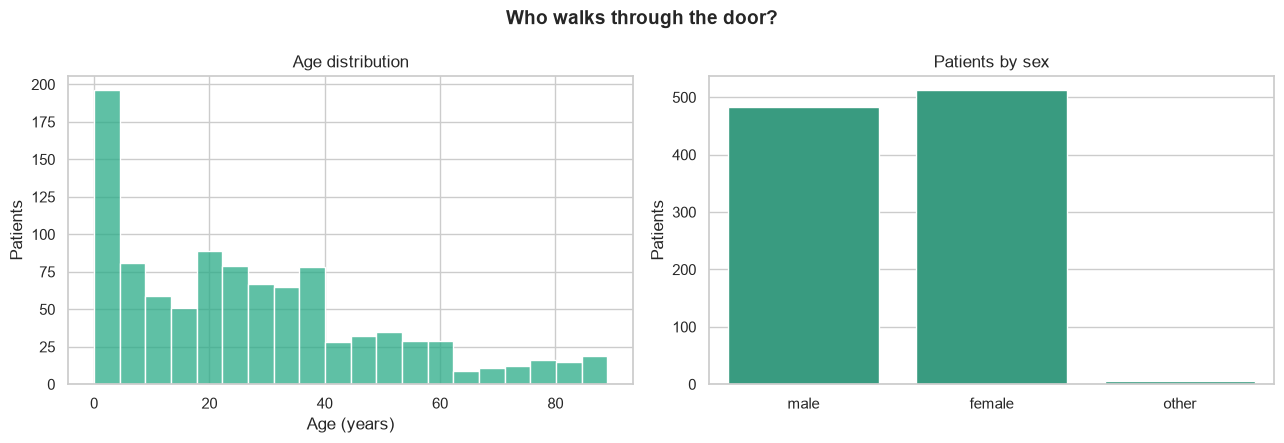

In [3]:
# Work out each patient's age from their date of birth
today = pd.Timestamp(date.today())
patients["age"] = ((today - patients["date_of_birth"]).dt.days / 365.25).astype(int)

# Two charts side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: age distribution
sns.histplot(data=patients, x="age", bins=20, color=MIRAI_GREEN, ax=axes[0])
axes[0].set_title("Age distribution")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Patients")

# Right: sex breakdown
sns.countplot(data=patients, x="sex", color=MIRAI_GREEN, ax=axes[1])
axes[1].set_title("Patients by sex")
axes[1].set_xlabel("")
axes[1].set_ylabel("Patients")

fig.suptitle("Who walks through the door?", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## What do they come for — and where do they go?

Once through the door, patients split into different parts of the hospital — most seen and sent home the same day, a smaller share admitted. And a handful of conditions account for most of the visits. Here's the clinical shape of the month.

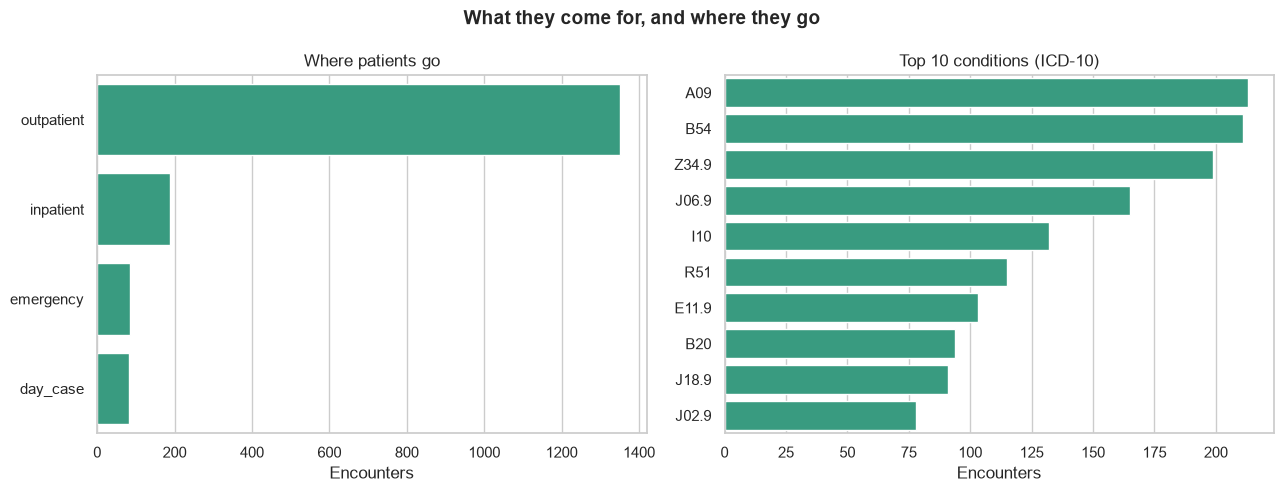

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: where patients go — encounter type
sns.countplot(
    data=encounters, y="encounter_type", color=MIRAI_GREEN,
    order=encounters["encounter_type"].value_counts().index, ax=axes[0],
)
axes[0].set_title("Where patients go")
axes[0].set_xlabel("Encounters")
axes[0].set_ylabel("")

# Right: top 10 conditions by diagnosis code
top_dx = encounters["primary_diagnosis_code"].value_counts().head(10).index
sns.countplot(
    data=encounters[encounters["primary_diagnosis_code"].isin(top_dx)],
    y="primary_diagnosis_code", color=MIRAI_GREEN,
    order=top_dx, ax=axes[1],
)
axes[1].set_title("Top 10 conditions (ICD-10)")
axes[1].set_xlabel("Encounters")
axes[1].set_ylabel("")

fig.suptitle("What they come for, and where they go", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Who pays?

Every visit is backed by someone — a national scheme, a private insurer, or the patient's own pocket. The payer mix shapes the hospital's whole financial life: how quickly money arrives, how much paperwork stands in the way, and how much risk sits in any single relationship. Here's who's behind the month's activity, by volume and by value.

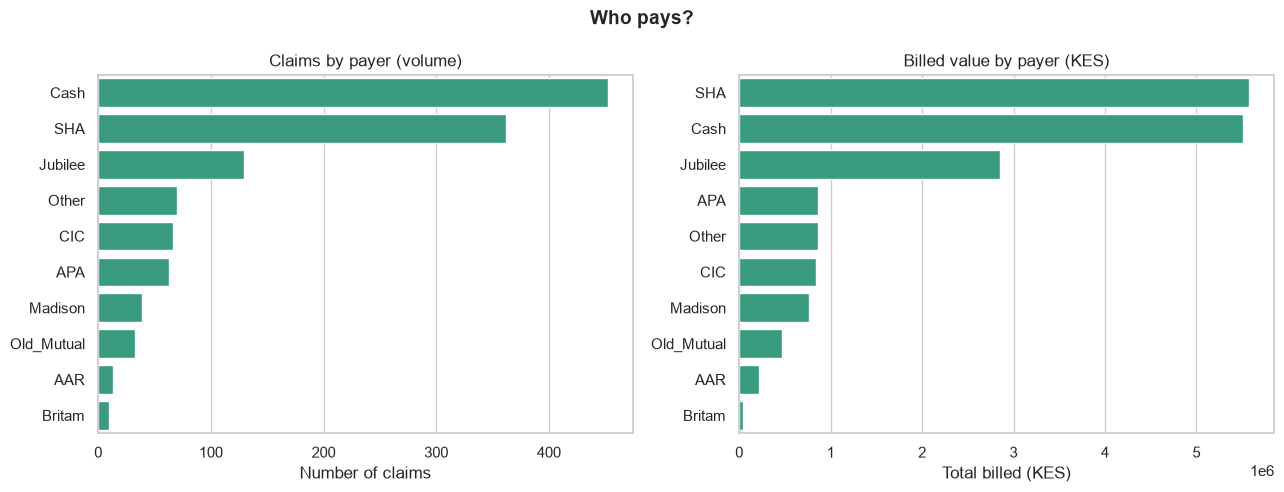

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: number of claims per payer
sns.countplot(
    data=claims, y="payer", color=MIRAI_GREEN,
    order=claims["payer"].value_counts().index, ax=axes[0],
)
axes[0].set_title("Claims by payer (volume)")
axes[0].set_xlabel("Number of claims")
axes[0].set_ylabel("")

# Right: total billed value per payer
revenue_by_payer = (
    claims.groupby("payer")["total_amount_kes"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
sns.barplot(
    data=revenue_by_payer, x="total_amount_kes", y="payer",
    color=MIRAI_GREEN, ax=axes[1],
)
axes[1].set_title("Billed value by payer (KES)")
axes[1].set_xlabel("Total billed (KES)")
axes[1].set_ylabel("")

fig.suptitle("Who pays?", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Where the money gets stuck

This is the part that keeps hospital finance teams up at night: claims that get rejected. A rejected claim is work already done — a patient seen, a service delivered — that the hospital may never be paid for. Cash payers can't reject (the money's already in hand), so this looks only at insurer and scheme claims.

> **A note on what you're seeing.** These rejection patterns are built into the synthetic data generator — they reflect the *kinds* of problems Mirai is designed to detect (late submissions, missing documentation, missing diagnoses), not findings about any real hospital. The point of this section is to show the questions Mirai answers, using data whose answers we already know.

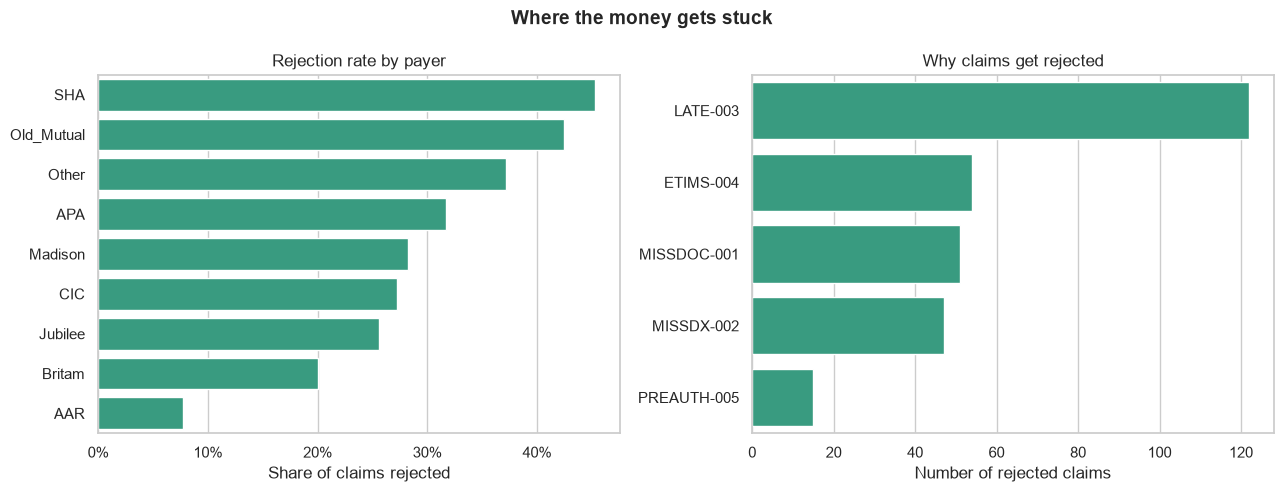

Overall insurer rejection rate: 36.8%
Total billed value of rejected claims: KES 5,072,224


In [6]:
# Insurer/scheme claims only — cash can't be rejected
insurer_claims = claims[claims["payer"] != "Cash"].copy()
insurer_claims["is_rejected"] = insurer_claims["status"] == "rejected"

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: rejection rate by payer
rate_by_payer = (
    insurer_claims.groupby("payer")["is_rejected"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
sns.barplot(data=rate_by_payer, x="is_rejected", y="payer",
            color=MIRAI_GREEN, ax=axes[0])
axes[0].set_title("Rejection rate by payer")
axes[0].set_xlabel("Share of claims rejected")
axes[0].set_ylabel("")
axes[0].xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

# Right: most common rejection reasons
top_reasons = (
    claims[claims["status"] == "rejected"]["rejection_reason_code"]
    .value_counts().head(8).index
)
sns.countplot(
    data=claims[(claims["status"] == "rejected")
                & (claims["rejection_reason_code"].isin(top_reasons))],
    y="rejection_reason_code", color=MIRAI_GREEN,
    order=top_reasons, ax=axes[1],
)
axes[1].set_title("Why claims get rejected")
axes[1].set_xlabel("Number of rejected claims")
axes[1].set_ylabel("")

fig.suptitle("Where the money gets stuck", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# The headline number
revenue_at_risk = claims[claims["status"] == "rejected"]["total_amount_kes"].sum()
overall_rate = insurer_claims["is_rejected"].mean()
print(f"Overall insurer rejection rate: {overall_rate:.1%}")
print(f"Total billed value of rejected claims: KES {revenue_at_risk:,.0f}")

## What this shows

In one month, this hospital saw a young, maternity-skewed population, overwhelmingly as outpatients, for a familiar set of conditions — and was paid by a mix of SHA, private insurers, and cash. The friction sits in the claims: roughly a third of insurer claims rejected, mostly for fixable process reasons, with real money attached.

That last chart is why Mirai exists. The work here was a rehearsal on synthetic data — but the same questions, asked of a real hospital's records, are the ones that turn rejected claims back into recovered revenue.

*All figures above are from synthetic data and describe the data generator, not any real hospital.*